# Lab 3: Decision Tree Classification
## Training, Evaluation & Overfitting — Telco Customer Churn

**Name:** Faryal Gul

**Student ID:** 023-24-0014

**Section:** B

**GitHub Profile:**

**Kaggle Profile:**

**Dataset:** Telco Customer Churn

**Dataset Source:** Kaggle — https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, and Decision Tree theory. Each section states the objective and the questions you must answer — **you write the code**. Do not just run code without interpreting it: every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [7]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


---

## 1. Problem Definition

Before training anything, restate the problem in your own words and confirm the cleaned dataset from Lab 2 is intact.

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`, `df['Churn'].value_counts()`

**Tasks**
1. Load `clean_churn.csv` (or re-run your Lab 2 cleaning). Verify its shape, column dtypes, and that there are no missing values remaining.
2. In 1–2 sentences, restate the ML problem: what exactly are you predicting, and why does it matter to the business?

In [8]:
# Task 1 — load and verify the cleaned dataset
df=pd.read_csv("clean_churn.csv")
df.dropna(subset=["TotalCharges"], inplace=True)
df.to_csv("clean_churn.csv", index=False)
print(df.shape)
print(df.dtypes)
print("Missing values after cleaning:")
print(df.isnull().sum())
print("Duplicate values : ",df.duplicated().sum())




(7010, 20)
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object
Missing values after cleaning:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCha

**Answer 2:**
The goal is to predict whether a customer will churn or not based on their customer information. This is important because the company can identify customers who are likely to leave and take actions to retain them.

---

## 2. Dataset Verification

Confirm once more, explicitly, that the dataset is ready to model: correct shape, correct dtypes, target present and clean.

In [9]:
# Additional verification if needed (dtypes, target check, etc.)
print("Shape : ",df.shape)
print("Churn present : ", "Churn" in df.columns)
print("Churn missing values : ",df["Churn"].isnull().sum())
print(df["Churn"].value_counts())


Shape :  (7010, 20)
Churn present :  True
Churn missing values :  0
Churn
No     5153
Yes    1857
Name: count, dtype: int64


---

## 3. Feature/Target Preparation

scikit-learn models require numeric input. Separate your target from your features, then convert any remaining categorical columns into numeric form.

*Concepts/functions you may find useful:* `pd.get_dummies(df, columns=[...])`, `df[col].map({...})`, `df.drop(columns=[...])`, `X.isnull().sum()`, `X.dtypes`

**Tasks**
3. Define `y` as the `Churn` column, encoded as 0/1. Define `X` as the remaining relevant columns — drop any identifier column still present.
4. Convert every remaining categorical column in `X` into numeric form. Briefly justify your choice of encoding method (e.g. one-hot vs. manual mapping).
5. Confirm `X` contains only numeric columns and has no missing values before moving on.

In [10]:
# Task 3 — define y and X
y=df["Churn"].map({ "No" : 0, "Yes" : 1 })
x=df.drop(columns=["Churn"])
print(x.shape)
print(y.shape)

(7010, 19)
(7010,)


In [11]:
# Task 4 — encode categorical columns in X
x=pd.get_dummies(x,drop_first=True)


In [12]:
# Task 5 — confirm X is fully numeric with no missing values
print(x.dtypes)
print(x.isnull().sum())

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes                             bool
StreamingTV_No inter

**Answer 4 (encoding method & justification):**
I used One-Hot Encoding (pd.get_dummies()) to convert categorical features into numeric 0/1 columns. This method is suitable because the categorical values do not have a meaningful numerical order, so one-hot encoding avoids imposing an artificial order between categories.

## 4. Train/Test Split

A model must be evaluated on data it has never seen. Hold out a test set before training anything.

*Concepts/functions you may find useful:* `train_test_split(X, y, test_size=..., random_state=..., stratify=y)`

**Tasks**
6. Split `X` and `y` into training and test sets (e.g. an 80/20 split). Why is `stratify=y` a sensible choice, given what you found about the target's class balance in Lab 2?
7. Report the shape of `X_train`, `X_test`, `y_train`, and `y_test`.

In [13]:
# Task 6 — train/test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [14]:
# Task 7 — report shapes
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5608, 30)
(1402, 30)
(5608,)
(1402,)


**Answer 6 (why stratify=y):**
I used stratify=y because the Churn target is imbalanced. It keeps approximately the same proportion of Churn=Yes and Churn=No in both the training and test sets.

## 5. Baseline Decision Tree

Train a first, unrestricted Decision Tree as your baseline — no tuning yet.

*Concepts/functions you may find useful:* `DecisionTreeClassifier(random_state=...)`, `.fit(X_train, y_train)`, `.predict(X)`, `.get_depth()`

**Tasks**
8. Train a `DecisionTreeClassifier` on the training data with default settings (only `random_state` fixed). Generate predictions on both the training and test sets.
9. What depth did scikit-learn actually grow this tree to on its own? Does that surprise you?

In [15]:
# Task 8 — train baseline Decision Tree and predict on train/test
model=DecisionTreeClassifier(random_state=42)
model.fit(x_train,y_train)
y_train_pred=model.predict(x_train)
y_test_pred=model.predict(x_test)

In [16]:
# Task 9 — check the fitted tree's depth
print("Depth of tree : ",model.get_depth())

Depth of tree :  24


**Answer 9:**
The Decision Tree grew to a depth of 24. This indicates that the unrestricted tree became quite deep and learned many detailed splits from the training data. This may indicate a risk of overfitting, which will be investigated by comparing training and test performance.

## 6. Model Evaluation

Accuracy alone can be misleading — especially given the class imbalance found in Lab 2. Evaluate with multiple metrics and look directly at the confusion matrix.

*Concepts/functions you may find useful:* `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`, `ConfusionMatrixDisplay`, `classification_report`

**Tasks**
10. Compute accuracy, precision, recall, and F1-score on the test set. Report them in a small table.
11. Plot the confusion matrix for the test set. How many actual churners did the model correctly catch, and how many did it miss?
12. Given Lab 2's finding about class imbalance, which metric(s) do you trust most for this problem, and why?

In [17]:
# Task 10 — compute accuracy, precision, recall, F1 on the test set
accuracy=accuracy_score(y_test,y_test_pred)
precision=precision_score(y_test,y_test_pred)
recall=recall_score(y_test,y_test_pred)
f1=f1_score(y_test,y_test_pred)
print("accuracy : ",accuracy)
print("precision : ",precision)
print("recall : ",recall)
print("f1 score : ",f1)

accuracy :  0.7268188302425107
precision :  0.48360655737704916
recall :  0.477088948787062
f1 score :  0.48032564450474896


**Task 10 — Results Table**

| Metric | Value  |
|---|--------|
| Accuracy | 72.68% |
| Precision | 48.36% |
| Recall | 47.70% |
| F1-score | 48.03% |

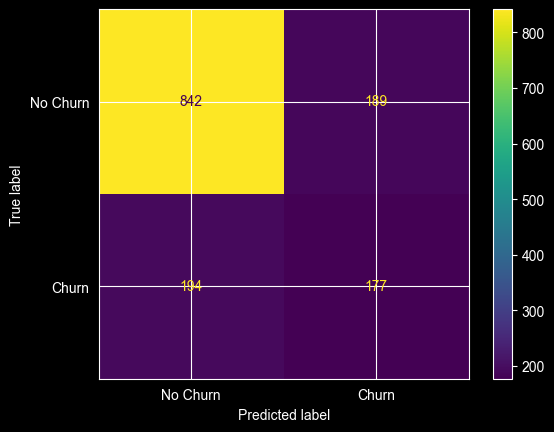

In [18]:
# Task 11 — plot the confusion matrix
cm=confusion_matrix(y_test,y_test_pred)
disp=ConfusionMatrixDisplay( confusion_matrix=cm, display_labels=["No Churn","Churn"])
disp.plot()
plt.show()

**Answer 11 (churners correctly caught vs. missed):**
churners correctly caught are 177
missed churners are 194

**Answer 12 (which metric(s) do you trust most, and why):**
Because the churn classes are imbalanced, I would not rely only on accuracy. Recall, precision, and F1-score are more important for this problem. Recall tells us how many actual churners the model successfully identified. Precision tells us how many of the customers predicted as churners were actually churners. F1-score gives a balance between precision and recall. Accuracy is still useful as an overall measure, but we should not trust it alone when the classes are imbalanced.

## 7. Overfitting Experiment

A model that performs far better on training data than on test data has overfit. Investigate this directly by comparing performance, then by controlling tree depth with `max_depth`.

*Concepts/functions you may find useful:* `accuracy_score(y_train, model.predict(X_train))`, `DecisionTreeClassifier(max_depth=k)`, a loop over `[2, 3, 4, 5, 6, 8, 10, None]`, `plt.plot(...)`

**Tasks**
13. Compare your baseline tree's accuracy on the training set vs. the test set. Is there a large gap? What does that suggest about the model?
14. Train several Decision Trees at different `max_depth` values (e.g. 2, 3, 4, 5, 6, 8, 10, and unrestricted). Record train accuracy and test accuracy for each in a results table.
15. Plot train accuracy and test accuracy against `max_depth` on the same chart. At roughly what depth does the model start to overfit? Explain how the chart shows this.

In [19]:
# Task 13 — compare baseline train vs. test accuracy
train_accuracy=accuracy_score(y_train,y_train_pred)
test_accuracy=accuracy_score(y_test,y_test_pred)
print(" Training accuracy : ",train_accuracy)
print(" Testing accuracy : ",test_accuracy)

 Training accuracy :  0.9980385164051355
 Testing accuracy :  0.7268188302425107


In [20]:
# Task 14 — loop over max_depth values, record train/test accuracy
depths = [2, 3, 4, 5, 6, 8, 10, None]
# YOUR CODE HERE
for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth, random_state=42)
    model.fit(x_train,y_train)
    train_accuracy=model.score(x_train,y_train)
    test_accuracy=model.score(x_test,y_test)
    print("Depth of tree : ",depth)
    print("Training accuracy : ",train_accuracy)
    print("Testing accuracy : ",test_accuracy)
    print()



Depth of tree :  2
Training accuracy :  0.7915477888730386
Testing accuracy :  0.7860199714693296

Depth of tree :  3
Training accuracy :  0.7915477888730386
Testing accuracy :  0.7860199714693296

Depth of tree :  4
Training accuracy :  0.7961840228245364
Testing accuracy :  0.7838801711840229

Depth of tree :  5
Training accuracy :  0.7999286733238231
Testing accuracy :  0.782453637660485

Depth of tree :  6
Training accuracy :  0.8072396576319544
Testing accuracy :  0.7895863052781741

Depth of tree :  8
Training accuracy :  0.8352353780313837
Testing accuracy :  0.7931526390870185

Depth of tree :  10
Training accuracy :  0.8732168330955777
Testing accuracy :  0.775320970042796

Depth of tree :  None
Training accuracy :  0.9980385164051355
Testing accuracy :  0.7268188302425107



**Answer 13:**
The training accuracy is 99.80%, while the testing accuracy is 72.68%. There is a large gap between the two accuracies, which suggests that the Decision Tree is overfitting the training data.


**Task 14 — Results Table**

| max_depth | Train Accuracy | Test Accuracy |
|---|----------------|---------------|
| 2 | 79.15%         | 78.60%        |
| 3 | 79.15%         | 78.60%        |
| 4 | 79.62%         | 78.39%        |
| 5 | 80.00%         | 78.25%        |
| 6 | 80.72%         | 78.96%        |
| 8 | 83.52%         | 79.32%        |
| 10 | 87.32%         | 77.53%        |
| None | 99.80%         | 72.68%        |

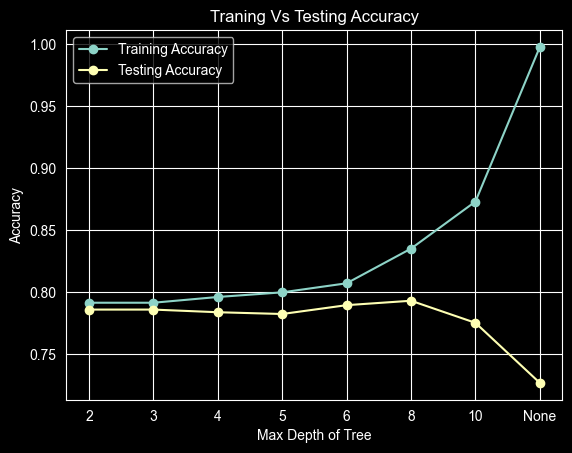

In [21]:
# Task 15 — plot train vs. test accuracy against max_depth
depth_labels=["2","3","4","5","6","8","10","None"]
train_accuracies=[    0.7915477888730386,
    0.7915477888730386,
    0.7961840228245364,
    0.7999286733238231,
    0.8072396576319544,
    0.8352353780313837,
    0.8732168330955777,
    0.9980385164051355]
test_accuracies=[
        0.7860199714693296,
    0.7860199714693296,
    0.7838801711840229,
    0.782453637660485,
    0.7895863052781741,
    0.7931526390870185,
    0.775320970042796,
    0.7268188302425107
]
plt.plot(depth_labels,train_accuracies,marker="o",label="Training Accuracy")
plt.plot(depth_labels,test_accuracies,marker="o",label="Testing Accuracy")
plt.xlabel("Max Depth of Tree")
plt.ylabel("Accuracy")
plt.title("Traning Vs Testing Accuracy")
plt.legend()
plt.show()

**Answer 15 (where overfitting starts, and why):**
As the depth increases, the training accuracy increases, but the testing accuracy does not always increase. The highest testing accuracy is 79.32% at depth 8. After depth 8, the testing accuracy starts to decrease while training accuracy keeps increasing. This shows that the model starts overfitting as the tree becomes too deep.

## 8. Model Comparison

Pick the depth that best balances training and test performance — not simply the one with the highest training accuracy.

**Tasks**
16. Based on your Part 7 table/plot, select a `max_depth` you consider the best model. Justify your choice in 2–3 sentences — it should not simply be the depth with the highest training accuracy.
17. Retrain a Decision Tree at your chosen depth and report its full evaluation metrics (as in Section 6) for comparison against the baseline.

 **Answer 16 (chosen max_depth and justification):**
 I would choose max_depth = 8 because it gives the highest testing accuracy of 79.32% among the tested depths. It also has a smaller gap between training accuracy (83.52%) and testing accuracy (79.32%), which suggests less overfitting. In addition, its precision, recall, and F1-score are better than the baseline model, so depth 8 gives a better overall balance between performance and generalization.

In [23]:
# Task 17 — retrain at chosen depth and report full evaluation metrics
final_model= DecisionTreeClassifier( max_depth=8, random_state=42)
final_model.fit(x_train,y_train)
y_train_pred_final=final_model.predict(x_train)
y_test_pred_final=final_model.predict(x_test)
print("Traning accuracy : ", accuracy_score(y_train,y_train_pred_final))
print("Testing accuracy : ", accuracy_score(y_test,y_test_pred_final))
print("Accuracy : ",accuracy_score(y_test,y_test_pred_final))
print("Precision : ", precision_score(y_test,y_test_pred_final))
print("Recall : ", recall_score(y_test,y_test_pred_final))
print("F1 Score : ", f1_score(y_test,y_test_pred_final))

Traning accuracy :  0.8352353780313837
Testing accuracy :  0.7931526390870185
Accuracy :  0.7931526390870185
Precision :  0.6310679611650486
Recall :  0.5256064690026954
F1 Score :  0.5735294117647058


**Task 17 — Baseline vs. Chosen Model**

| Metric | Baseline (unrestricted) | Chosen Model (max_depth = 8) |
|---|-------------------------|------------------------------|
| Accuracy | 72.68%                  | 79.31%                       |
| Precision | 48.36%                  | 63.10%                       |
| Recall | 47.70%                  | 52.56%                       |
| F1-score | 48.03%                  | 57.35%                       |

---

## 9. Feature Importance

Look inside your chosen model to see what it actually learned.

*Concepts/functions you may find useful:* `model.feature_importances_`, `pd.Series(importances, index=X.columns).sort_values()`, `plt.barh(...)`

**Task**
18. Extract and visualize `feature_importances_` for your chosen model. Which 3–5 features matter most?

In [25]:
# Task 18 — extract and visualize feature importances
important_series=pd.Series( final_model.feature_importances_, index=x.columns).sort_values(ascending=False)
print(important_series)

tenure                                   0.321495
InternetService_Fiber optic              0.260086
TotalCharges                             0.105608
MonthlyCharges                           0.077483
Contract_Two year                        0.043749
Contract_One year                        0.026861
PaymentMethod_Electronic check           0.025357
OnlineSecurity_No internet service       0.017913
MultipleLines_Yes                        0.014865
OnlineSecurity_Yes                       0.013028
TechSupport_Yes                          0.012746
PaperlessBilling_Yes                     0.011880
OnlineBackup_No internet service         0.011779
OnlineBackup_Yes                         0.009247
SeniorCitizen                            0.009241
DeviceProtection_Yes                     0.006917
Partner_Yes                              0.006565
PhoneService_Yes                         0.005814
StreamingMovies_Yes                      0.005593
PaymentMethod_Mailed check               0.005422


**Answer 18 (top 3–5 features):**
The top 5 most important features are tenure, InternetService_Fiber optic, TotalCharges, MonthlyCharges, and Contract_Two year.

---

## 10. Interpretation

Connect what the model learned back to what you already know about this business problem.

**Task**
19. In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the patterns you saw then?

**Answer 19:**
The model results agree with some of the patterns we found in Lab 2. Tenure and MonthlyCharges are important features, and in Lab 2 we found that churned customers usually had lower tenure and higher monthly charges. Contract_Two year is also an important feature, which agrees with our finding that contract type is related to churn.

---

## 11. Conclusion

Step back from the code and summarize what you built and learned.

**Tasks**
20. Write a short conclusion (4–6 sentences): which model did you land on, how well does it perform, and what are its main limitations?
21. What would you try next if you had more time (e.g. a different algorithm, more feature engineering, handling class imbalance)? Describe it — do not implement it here.

**Answer 20 — Conclusion:**
In this lab, I built a Decision Tree model to predict customer churn. I selected max_depth = 8 because it gave the best testing accuracy among the tested depths and had a smaller gap between training and testing accuracy. The final model achieved 79.32% testing accuracy, with 63.11% precision, 52.56% recall, and 57.35% F1-score. The model still has some limitations because the recall is not very high, so it misses some actual churn customers. Also, the dataset has class imbalance, so accuracy alone cannot fully describe the model's performance.

**Answer 21 — Next steps:**
If I had more time, I would try another machine learning algorithm and compare its performance with the Decision Tree. I would also try handling the class imbalance so that the model can identify more actual churn customers. I could also try more feature engineering to create useful features from the existing data.

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
- [ ] Section 1 — Problem Definition
- [ ] Section 2 — Dataset Verification
- [ ] Section 3 — Feature/Target Preparation (with encoding justified)
- [ ] Section 4 — Train/Test Split
- [ ] Section 5 — Baseline Decision Tree
- [ ] Section 6 — Model Evaluation (accuracy, precision, recall, F1, confusion matrix — all with interpretation)
- [ ] Section 7 — Overfitting Experiment (results table + plot + explanation)
- [ ] Section 8 — Model Comparison (chosen depth justified, not just highest training accuracy)
- [ ] Section 9 — Feature Importance (extracted, visualized, and discussed)
- [ ] Section 10 — Interpretation (connected to Lab 2's EDA)
- [ ] Section 11 — Conclusion (limitations + next steps)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted